In [1]:
using DelimitedFiles
using PeriodicOrbitTTV

using JLD2

using PyPlot
using LaTeXStrings
using Distributions, LinearAlgebra, StatsBase

In [2]:
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = true

true

In [3]:
# Load the data for all three noise levels
obj_01s = jldopen("run_freq_multi_noise_all_01_01s.jld2");
obj_03s = jldopen("run_freq_multi_noise_all_01_03s.jld2");
obj_10s = jldopen("run_freq_multi_noise_all_01_10s.jld2");

# $\sigma = 1$ second

In [4]:
clean_params = vec(readdlm("../frequentist/sample_orbit_v1.in"))
clean_params[4:8] .= rem2pi.(clean_params[4:8], RoundNearest)

function get_valid_indices(optres_arr)
    idx_arr = []
    for i in eachindex(optres_arr)
        if isassigned(optres_arr[i], length(optres_arr[i]))
            push!(idx_arr, i)
        end
    end

    return idx_arr
end

function find_converged_pott_idx(optres_arr, po_weight; valid_idx=valid_idx)
    idx_arr = []
    for i in eachindex(optres_arr)
        if i in valid_idx
            chi2 = sum(abs2, optres_arr[i][end].resid[1:26])
            chi2_tt = sum(abs2, optres_arr[i][end].resid[27:end])
        
            if (chi2 ./ po_weight < 1e-12) & (chi2_tt <= 1e2)
                push!(idx_arr, i)
            end
        end
    end

    return idx_arr
end

function find_converged_bad_tt_idx(optres_arr, po_weight; valid_idx=valid_idx)
    idx_arr = []
    for i in eachindex(optres_arr)
        if i in valid_idx
            chi2 = sum(abs2, optres_arr[i][end].resid[1:26])
            chi2_tt = sum(abs2, optres_arr[i][end].resid[27:end])
        
            if (chi2 ./ po_weight < 1e-12) & (chi2_tt > 1e3)
                push!(idx_arr, i)
            end
        end
    end

    return idx_arr
end

column_display = [L"e_{1}", L"e_{2}", L"e_{3}", 
    L"M_1", L"M_2", L"M_3",
    L"\Delta \omega_{21}", L"\Delta \omega_{32}",
    L"\delta P_{23}",
    L"P_1",
    L"m_1", L"m_2", L"m_3",
    L"\kappa", L"\omega_1", L"T_{sys}"];

In [5]:
valid_idx = get_valid_indices(obj_01s["optres"])
converged_idx = find_converged_pott_idx(obj_01s["optres"], obj_01s["weights"][end]);

# Load all converged runs
params_all = reduce(hcat, [[(obj_01s["optres"][i][100].param .* obj_01s["scaler"][i])[param_idx] for i in converged_idx] for param_idx in 1:16]);
params_all_tt = reduce(hcat, [[(obj_01s["optres"][i][1].param .* obj_01s["scaler"][i])[param_idx] for i in converged_idx] for param_idx in 1:16]);

# Parameters of interest
pois = [1, 2, 3, 10, 11, 12, 13];

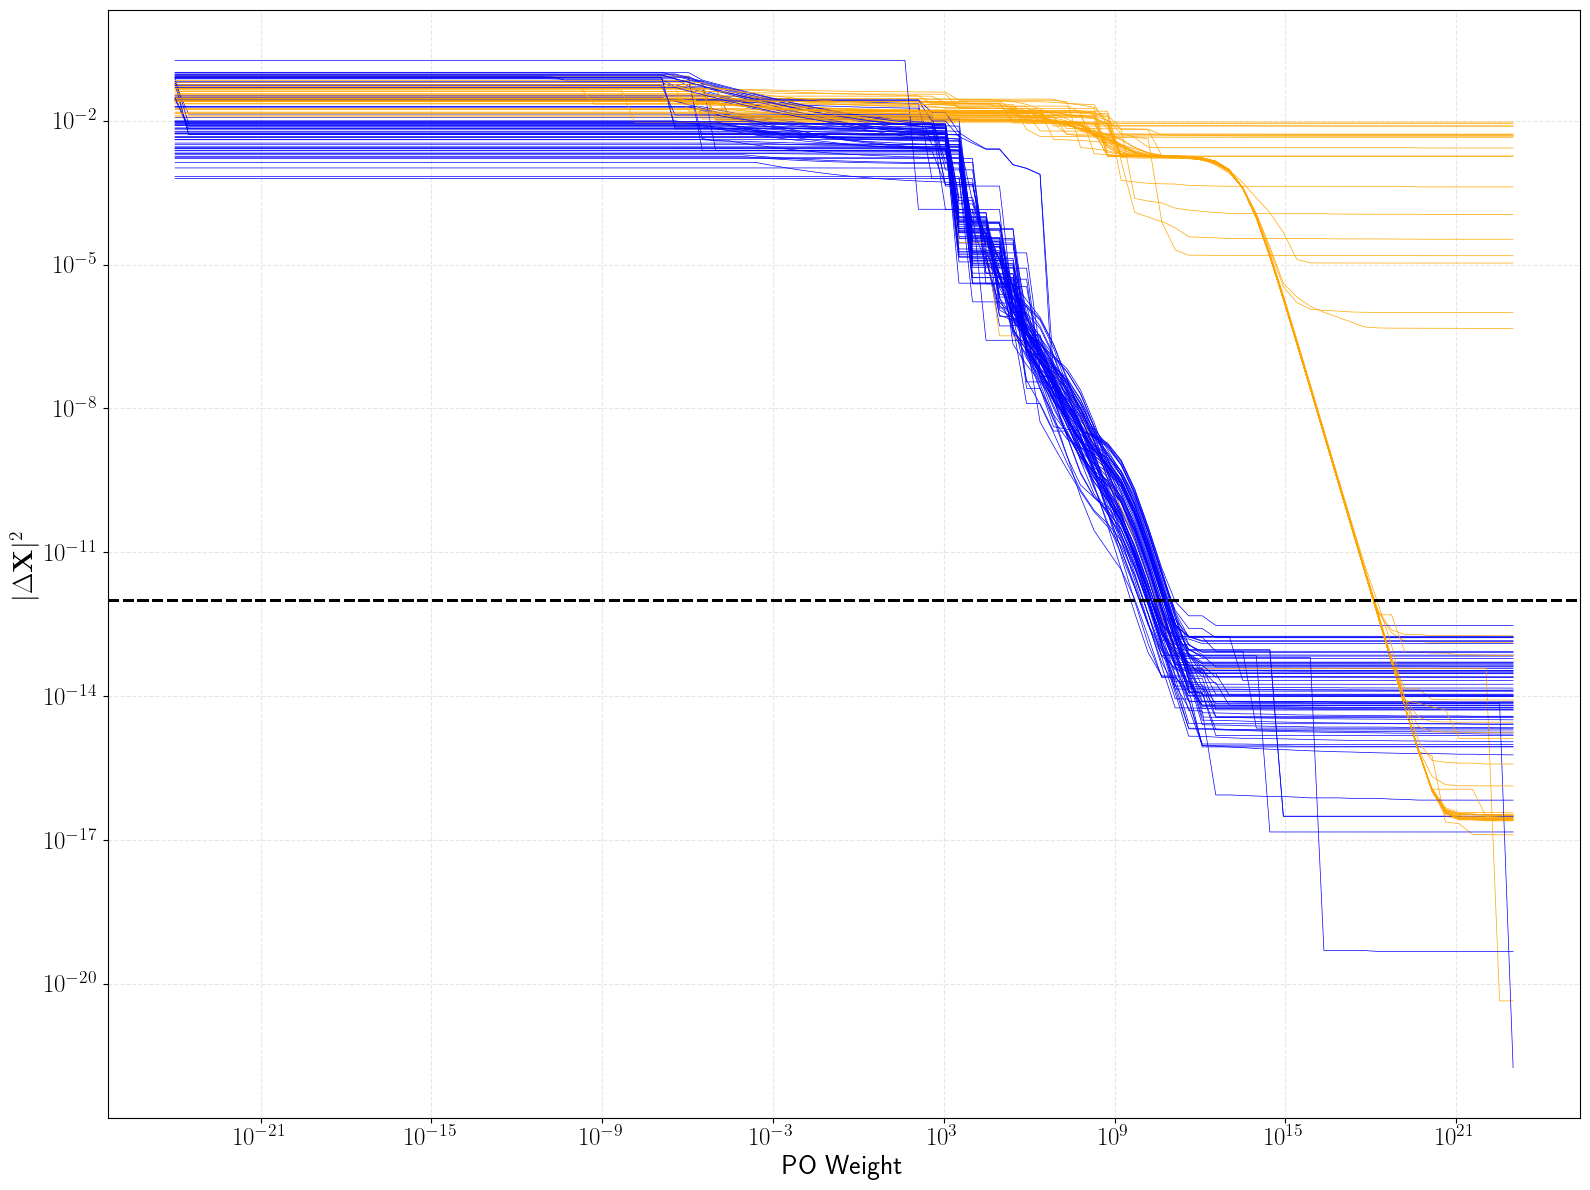

In [6]:
fig, ax = subplots(figsize=(16,12), tight_layout=true)

for j in valid_idx
    chi2 = [sum(abs2, obj_01s["optres"][j][i].resid[1:10]) for i in 1:100]
    po_weights = obj_01s["weights"][1:100]

    if !(j in converged_idx)
        ax.plot(po_weights, chi2 ./ po_weights, color="orange", linewidth=0.5)
    else
        ax.plot(po_weights, chi2 ./ po_weights, color="blue", linewidth=0.5)
    end

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("PO Weight", fontsize=20)
    ax.set_ylabel(L"|\Delta \mathbf{X}|^2", fontsize=20)

    ax.tick_params("both", labelsize=18)

    ax.axhline(1e-12, linestyle="--", linewidth=2, color="black")

    ax.grid(linestyle="--", alpha=0.3)
end

# fig.savefig("figures/main_po_chi2_diff_rescaled.pdf")

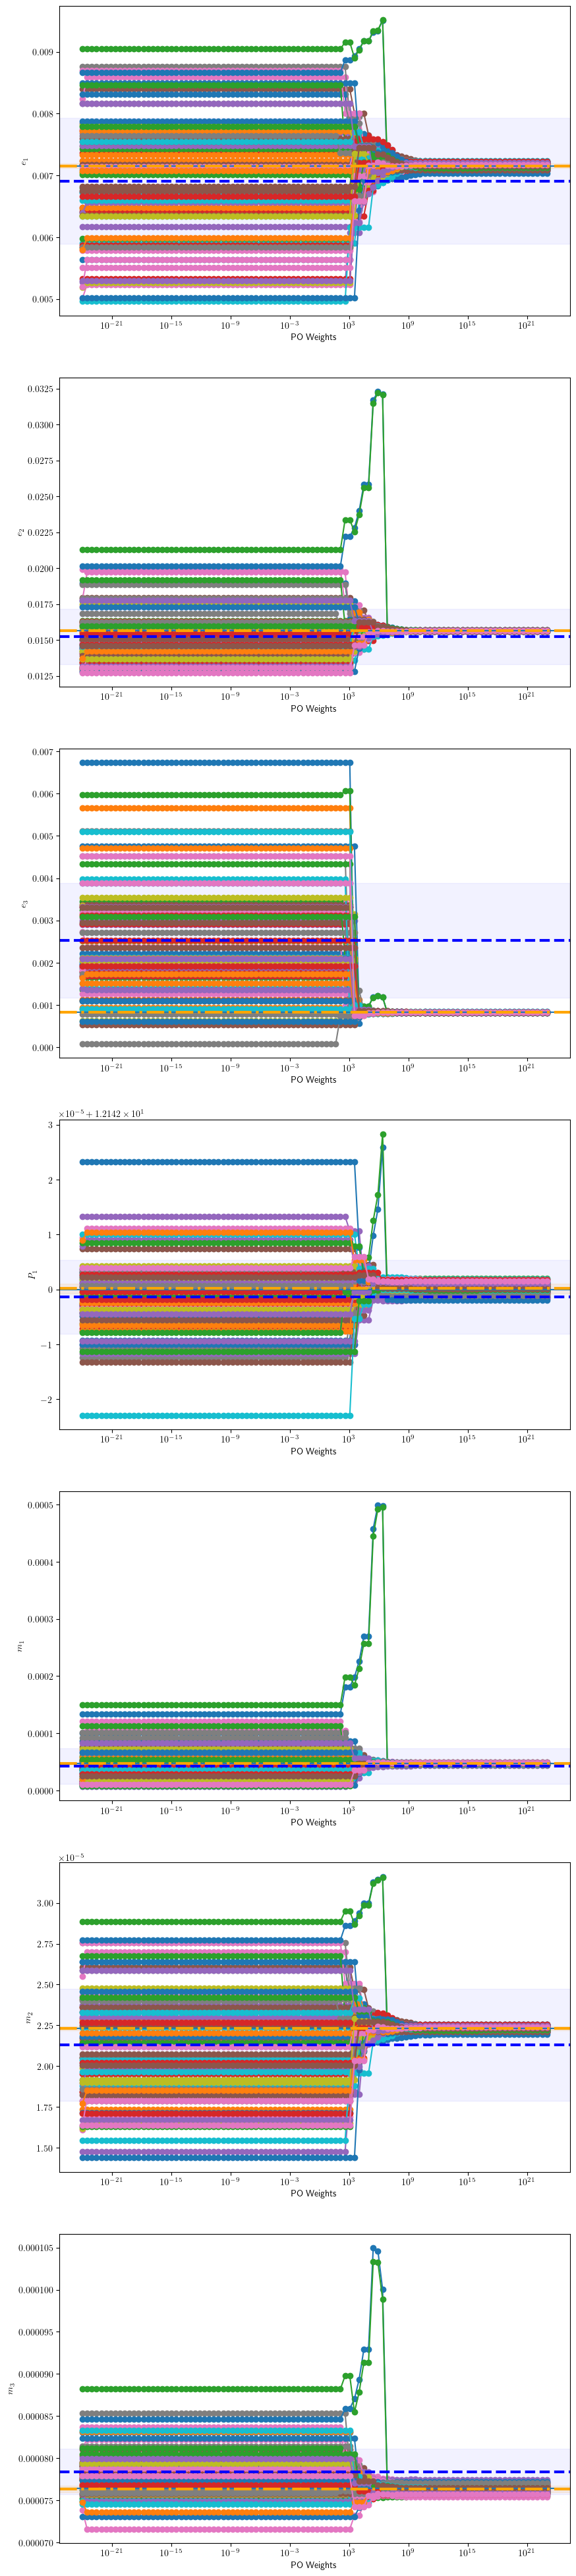

In [7]:
fig, ax = subplots(7, 1, figsize=(10,50))
po_weights = obj_01s["weights"][1:100]

for (idx, param_idx) in enumerate(pois)
    e1_matrix = reduce(hcat, [[(obj_01s["optres"][i][j].param .* obj_01s["scaler"][i])[param_idx] for j in 1:100] for i in converged_idx])    
    
    for i in 1:size(e1_matrix, 2)
        ax[idx].plot(po_weights, e1_matrix[:,i], marker="o")
    end
    
    ax[idx].set_xscale("log")
    ax[idx].set_xlabel("PO Weights")
    
    pott_params = params_all[:, param_idx]
    tt_params = params_all_tt[:, param_idx]
    
    ax[idx].axhspan(mean(pott_params) - std(pott_params), mean(pott_params) + std(pott_params), color="orange", alpha=0.1)
    ax[idx].axhspan(mean(tt_params) - std(tt_params), mean(tt_params) + std(tt_params), color="blue", alpha=0.05)
    
    ax[idx].axhline(clean_params[param_idx])
    ax[idx].axhline(mean(pott_params), linestyle="-.", color="orange", linewidth=3)
    ax[idx].axhline(mean(tt_params), linestyle="--", color="blue", linewidth=3)

    ax[idx].set_ylabel(column_display[param_idx])
# yscale("log")
end

# Versus PO Weights

In [8]:
valid_idx_01s = get_valid_indices(obj_01s["optres"])
converged_idx_01s = find_converged_pott_idx(obj_01s["optres"], obj_01s["weights"][end]; valid_idx=valid_idx_01s);

valid_idx_03s = get_valid_indices(obj_03s["optres"])
converged_idx_03s = find_converged_pott_idx(obj_03s["optres"], obj_03s["weights"][end]; valid_idx=valid_idx_03s);

valid_idx_10s = get_valid_indices(obj_10s["optres"])
converged_idx_10s = find_converged_pott_idx(obj_10s["optres"], obj_10s["weights"][end]; valid_idx=valid_idx_10s);

# # Load all converged runs
# params_all = reduce(hcat, [[(obj_01s["optres"][i][100].param .* obj_01s["scaler"][i])[param_idx] for i in converged_idx] for param_idx in 1:16]);
# params_all_tt = reduce(hcat, [[(obj_01s["optres"][i][1].param .* obj_01s["scaler"][i])[param_idx] for i in converged_idx] for param_idx in 1:16]);

# # Parameters of interest
# pois = [1, 2, 3, 10, 11, 12, 13];

In [9]:
valid_all = intersect(valid_idx_01s, valid_idx_03s, valid_idx_10s)
converged_all = intersect(converged_idx_01s, converged_idx_03s, converged_idx_10s)

19-element Vector{Any}:
   7
  28
  32
  41
  57
  59
  62
  64
  66
  78
  79
  87
  88
  91
 101
 103
 110
 123
 124

pindx = 7


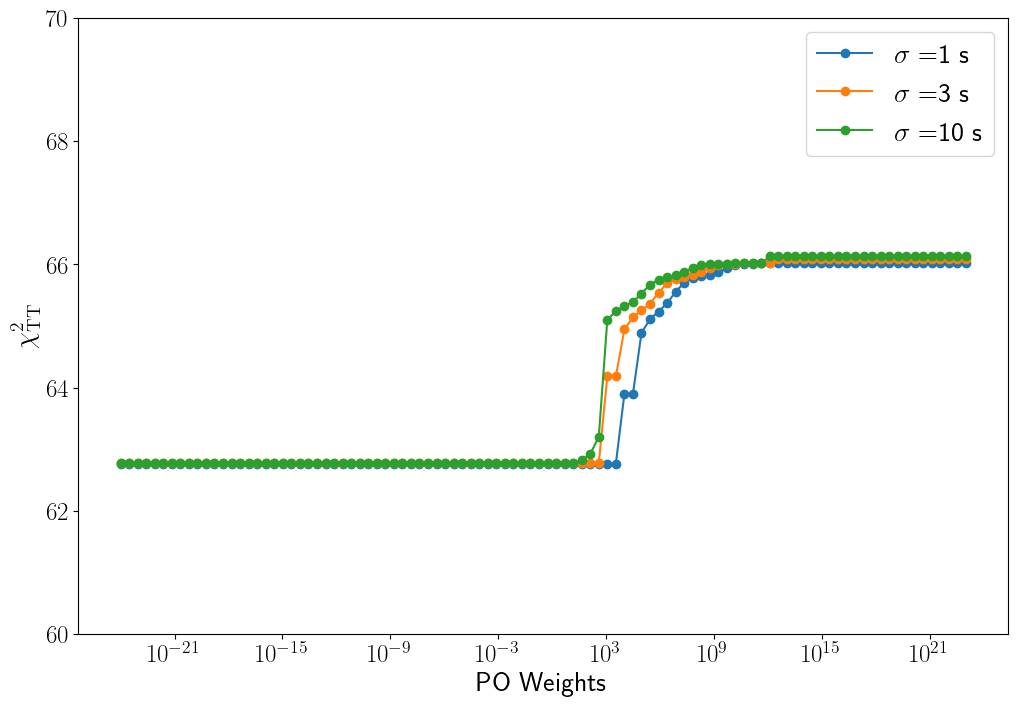

PyObject <matplotlib.legend.Legend object at 0x150cfee40>

In [10]:
fig, ax = subplots(figsize=(12,8))

po_weights = obj_01s["weights"][1:100]

pindx = converged_all[1]
@show pindx

chi2_01s = [sum(abs2, obj_01s["optres"][pindx][i].resid[27:end]) for i in 1:100]
chi2_03s = [sum(abs2, obj_03s["optres"][pindx][i].resid[27:end]) for i in 1:100]
chi2_10s = [sum(abs2, obj_10s["optres"][pindx][i].resid[27:end]) for i in 1:100]

ax.plot(po_weights, chi2_01s, marker="o", label=L"\sigma ="* "1 s")
ax.plot(po_weights, chi2_03s, marker="o", label=L"\sigma ="* "3 s")
ax.plot(po_weights, chi2_10s, marker="o", label=L"\sigma ="* "10 s")

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_ylim(60, 70)

ax.tick_params(labelsize=18)

ax.set_ylabel(L"\chi^2_\mathrm{TT}", fontsize=20)
ax.set_xlabel("PO Weights", fontsize=20)

ax.legend(fontsize=20)

# fig.savefig("figures/chi2_all_weights.pdf")

pindx = 7


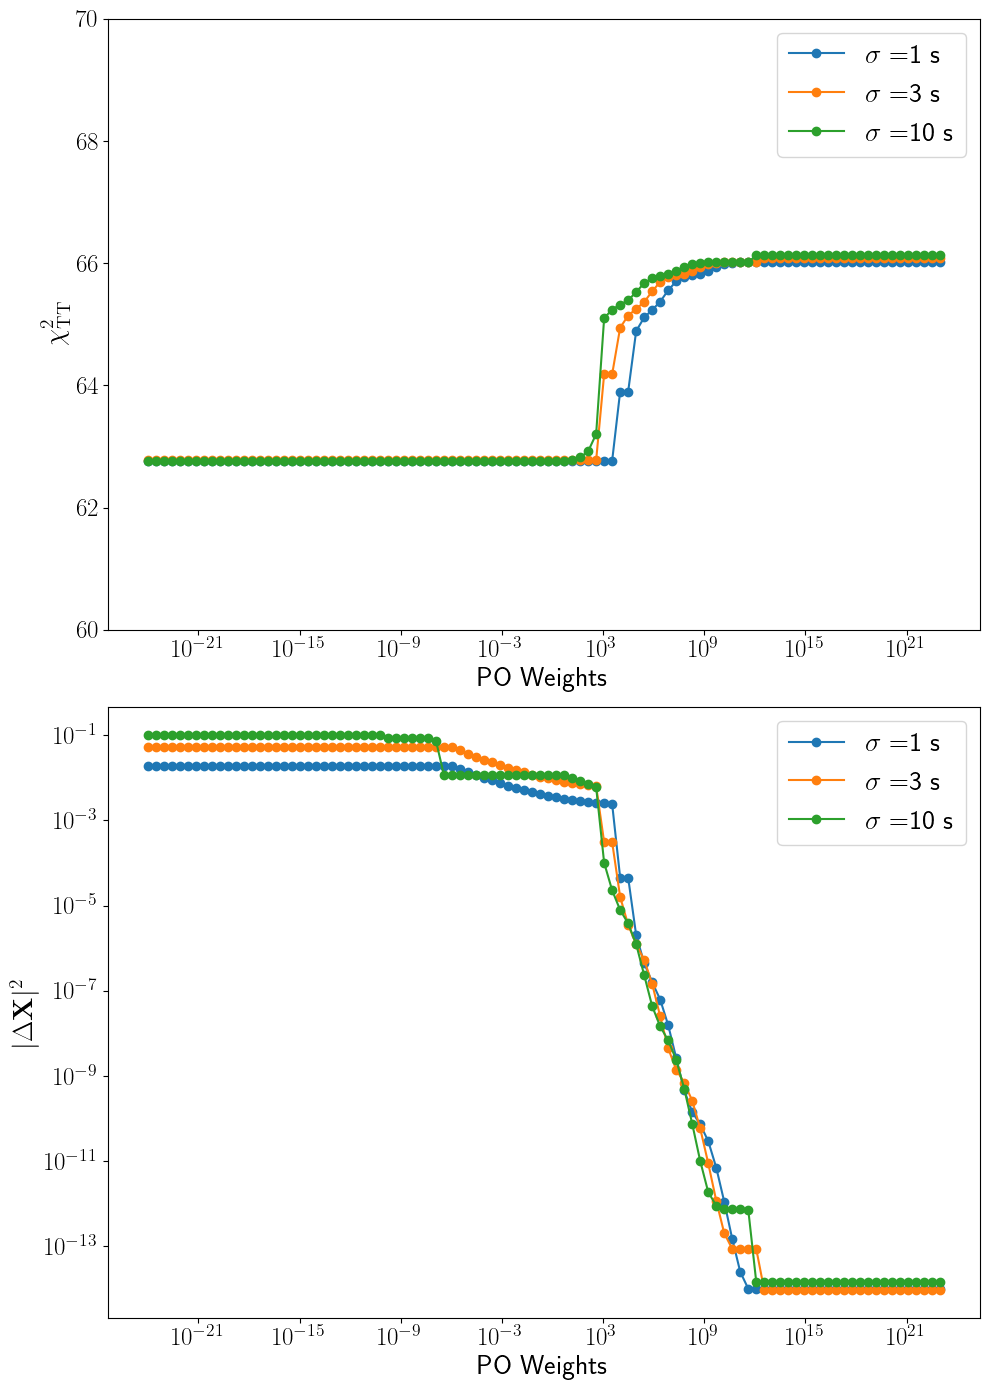

In [11]:
fig, ax = subplots(2, 1, figsize=(10,14), tight_layout=true)

po_weights = obj_01s["weights"][1:100]

pindx = converged_all[1]
@show pindx

chi2_01s = [sum(abs2, obj_01s["optres"][pindx][i].resid[27:end]) for i in 1:100]
chi2_03s = [sum(abs2, obj_03s["optres"][pindx][i].resid[27:end]) for i in 1:100]
chi2_10s = [sum(abs2, obj_10s["optres"][pindx][i].resid[27:end]) for i in 1:100]

ax[1].plot(po_weights, chi2_01s, marker="o", label=L"\sigma ="* "1 s")
ax[1].plot(po_weights, chi2_03s, marker="o", label=L"\sigma ="* "3 s")
ax[1].plot(po_weights, chi2_10s, marker="o", label=L"\sigma ="* "10 s")

ax[1].set_xscale("log")
# ax[1].set_yscale("log")

ax[1].set_ylim(60, 70)

ax[1].tick_params(labelsize=18)

ax[1].set_ylabel(L"\chi^2_\mathrm{TT}", fontsize=20)
ax[1].set_xlabel("PO Weights", fontsize=20)

ax[1].legend(fontsize=20)

# ====
chi2_01s_po = [sum(abs2, obj_01s["optres"][pindx][i].resid[1:10]) for i in 1:100]
chi2_03s_po = [sum(abs2, obj_03s["optres"][pindx][i].resid[1:10]) for i in 1:100]
chi2_10s_po = [sum(abs2, obj_10s["optres"][pindx][i].resid[1:10]) for i in 1:100]

ax[2].plot(po_weights, chi2_01s_po ./ po_weights, marker="o", label=L"\sigma ="* "1 s")
ax[2].plot(po_weights, chi2_03s_po ./ po_weights, marker="o", label=L"\sigma ="* "3 s")
ax[2].plot(po_weights, chi2_10s_po ./ po_weights, marker="o", label=L"\sigma ="* "10 s")

ax[2].set_xscale("log")
ax[2].set_yscale("log")

# ax[2].set_ylim(50, 70)

ax[2].tick_params(labelsize=18)

ax[2].set_ylabel(L"|\Delta \mathbf{X}|^2", fontsize=20)
ax[2].set_xlabel("PO Weights", fontsize=20)

ax[2].legend(fontsize=20)

fig.savefig("figures/chi2_all_weights.pdf")

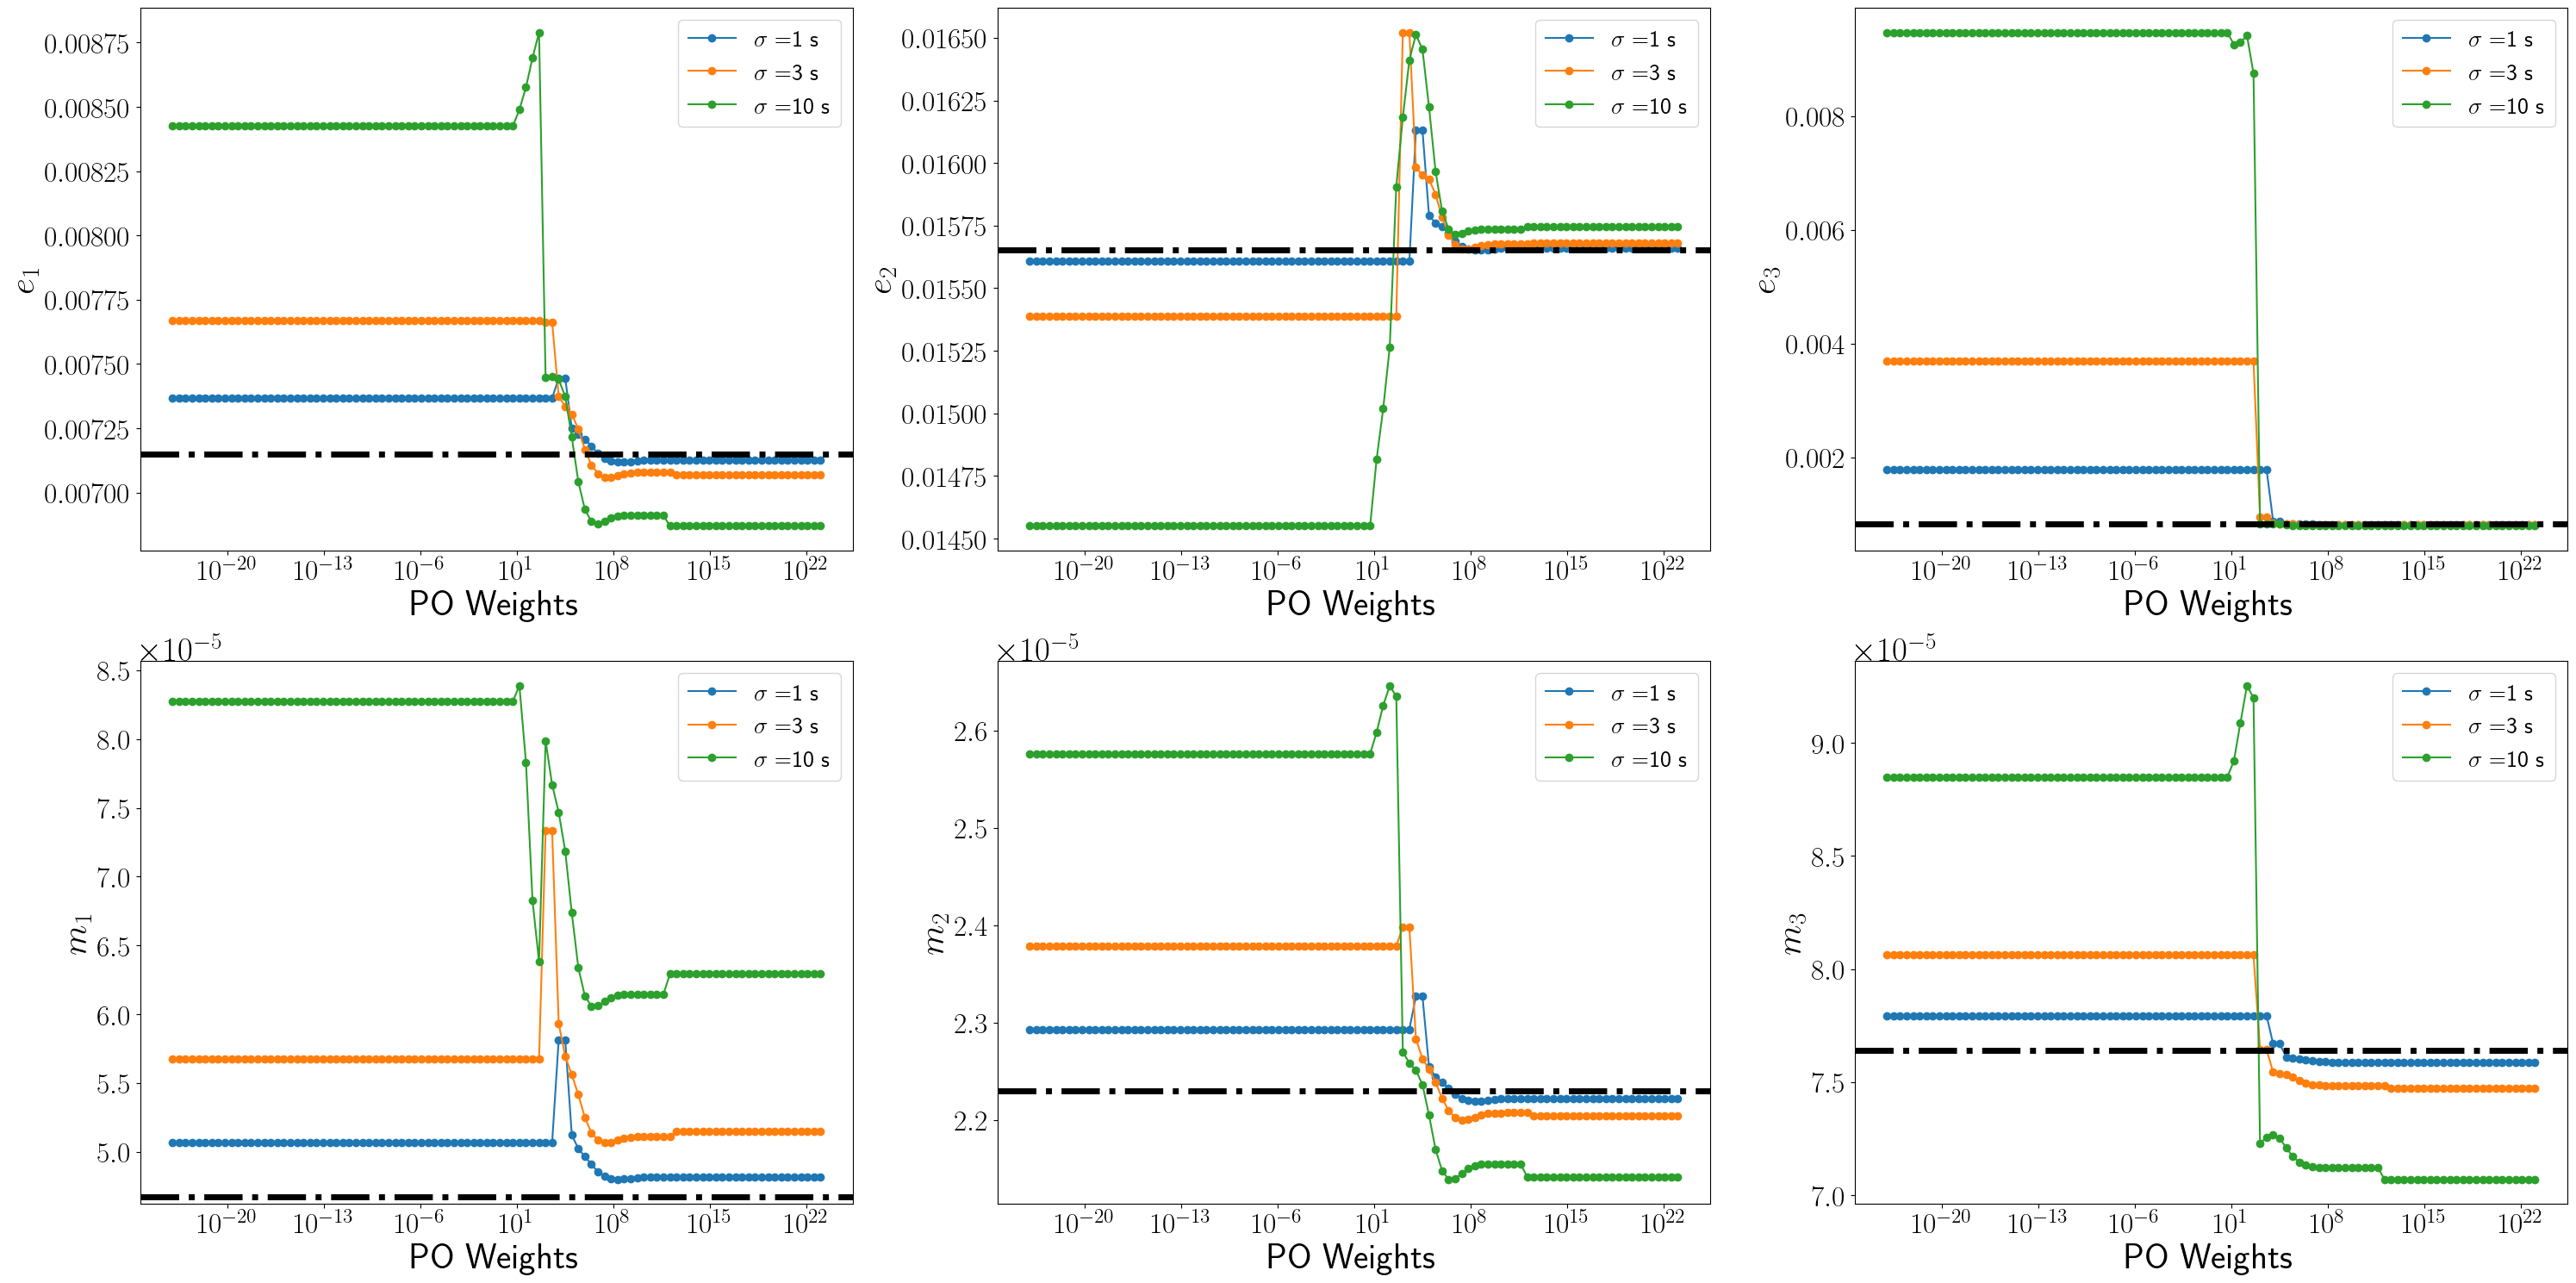

In [12]:
# pois = [1, 2, 3, 11, 12, 13];
pois = [1, 11, 2, 12, 3, 13];

fig, ax = subplots(2, 3, figsize=(30,15), tight_layout=true)
po_weights = obj_01s["weights"][1:100]

for (idx, param_idx) in enumerate(pois)
    matrix_01 = reduce(hcat, [obj_01s["optres"][converged_all[1]][i].param .* obj_01s["scaler"][i] for i in 1:100])
    matrix_03 = reduce(hcat, [obj_03s["optres"][converged_all[1]][i].param .* obj_03s["scaler"][i] for i in 1:100])
    matrix_10 = reduce(hcat, [obj_10s["optres"][converged_all[1]][i].param .* obj_10s["scaler"][i] for i in 1:100])
    
    ax[idx].plot(po_weights, matrix_01[param_idx,:], marker="o", label=L"\sigma ="* "1 s")
    ax[idx].plot(po_weights, matrix_03[param_idx,:], marker="o", label=L"\sigma ="* "3 s")
    ax[idx].plot(po_weights, matrix_10[param_idx,:], marker="o", label=L"\sigma ="* "10 s")
    
    ax[idx].set_xscale("log")
    ax[idx].set_xlabel("PO Weights", fontsize=30)
  
    ax[idx].axhline(clean_params[param_idx], linewidth=5, linestyle="-.", c="k")

    ax[idx].set_ylabel(column_display[param_idx], fontsize=30)

    ax[idx].tick_params("both", labelsize=24)
    ax[idx].get_yaxis().get_offset_text().set_fontsize(28)

    ax[idx].legend(fontsize=20)
end

fig.savefig("figures/main_elems_plots.pdf")

# Longer TTV

In [13]:
function to_matrix(tt::Matrix{T}; err=0.) where T <: Real
    tt_mat = Matrix{T}(undef, 0, 4)
    
    for i in 1:size(tt, 1), j in 1:size(tt, 2)
        if tt[i,j] != 0.0
            tt_mat = vcat(tt_mat, [i-1, j-1, tt[i,j], err]')
        end
    end

    errors = rand(Normal(0., err), size(tt_mat, 1))
    tt_mat[:,3] .= tt_mat[:,3] + errors
    
    return tt_mat
end

linear(x, m, c) = m*x + c

# Clean orbit
orbparams = OrbitParameters(3, [0.5], 500.)
optparams_0 = OptimParameters(3, clean_params)

orbit_0 = Orbit(3, optparams_0, orbparams)
tt = compute_tt(orbit_0, orbparams.obstmax);

# Clean orbit long
orbparams = OrbitParameters(3, [0.5], 6000.)
optparams_0_long = OptimParameters(3, clean_params)

orbit_0_long = Orbit(3, optparams_0_long, orbparams)
tt_long = compute_tt(orbit_0_long, orbparams.obstmax);

# Noisy orbit POTT (3 s)
params_all = reduce(hcat, [[(obj_03s["optres"][i][100].param .* obj_03s["scaler"][i])[param_idx] for i in converged_all] for param_idx in 1:16]);
orbparams = OrbitParameters(3, [0.5], 500.)
optparams_1 = OptimParameters(3, params_all[1,:])

orbit_1 = Orbit(3, optparams_1, orbparams)
tt_1 = compute_tt(orbit_1, orbparams.obstmax);

# Noisy orbit POTT long (3 s)
params_all = reduce(hcat, [[(obj_03s["optres"][i][100].param .* obj_03s["scaler"][i])[param_idx] for i in converged_all] for param_idx in 1:16]);
orbparams = OrbitParameters(3, [0.5], 6000.)
optparams_1_long = OptimParameters(3, params_all[1,:])

orbit_1_long = Orbit(3, optparams_1_long, orbparams)
tt_1_long = compute_tt(orbit_1_long, orbparams.obstmax);

# Noisy orbit TT (3 s)
params_all_tt = reduce(hcat, [[(obj_03s["optres"][i][1].param .* obj_03s["scaler"][i])[param_idx] for i in converged_all] for param_idx in 1:16]);
orbparams = OrbitParameters(3, [0.5], 500.)
optparams_2 = OptimParameters(3, params_all_tt[1,:])

orbit_2 = Orbit(3, optparams_2, orbparams)
tt_2 = compute_tt(orbit_2, orbparams.obstmax);

# Noisy orbit TT long (3 s)
params_all_tt = reduce(hcat, [[(obj_03s["optres"][i][1].param .* obj_03s["scaler"][i])[param_idx] for i in converged_all] for param_idx in 1:16]);
orbparams = OrbitParameters(3, [0.5], 6000.)
optparams_2_long = OptimParameters(3, params_all_tt[1,:])

orbit_2_long = Orbit(3, optparams_2_long, orbparams)
tt_2_long = compute_tt(orbit_2_long, orbparams.obstmax);

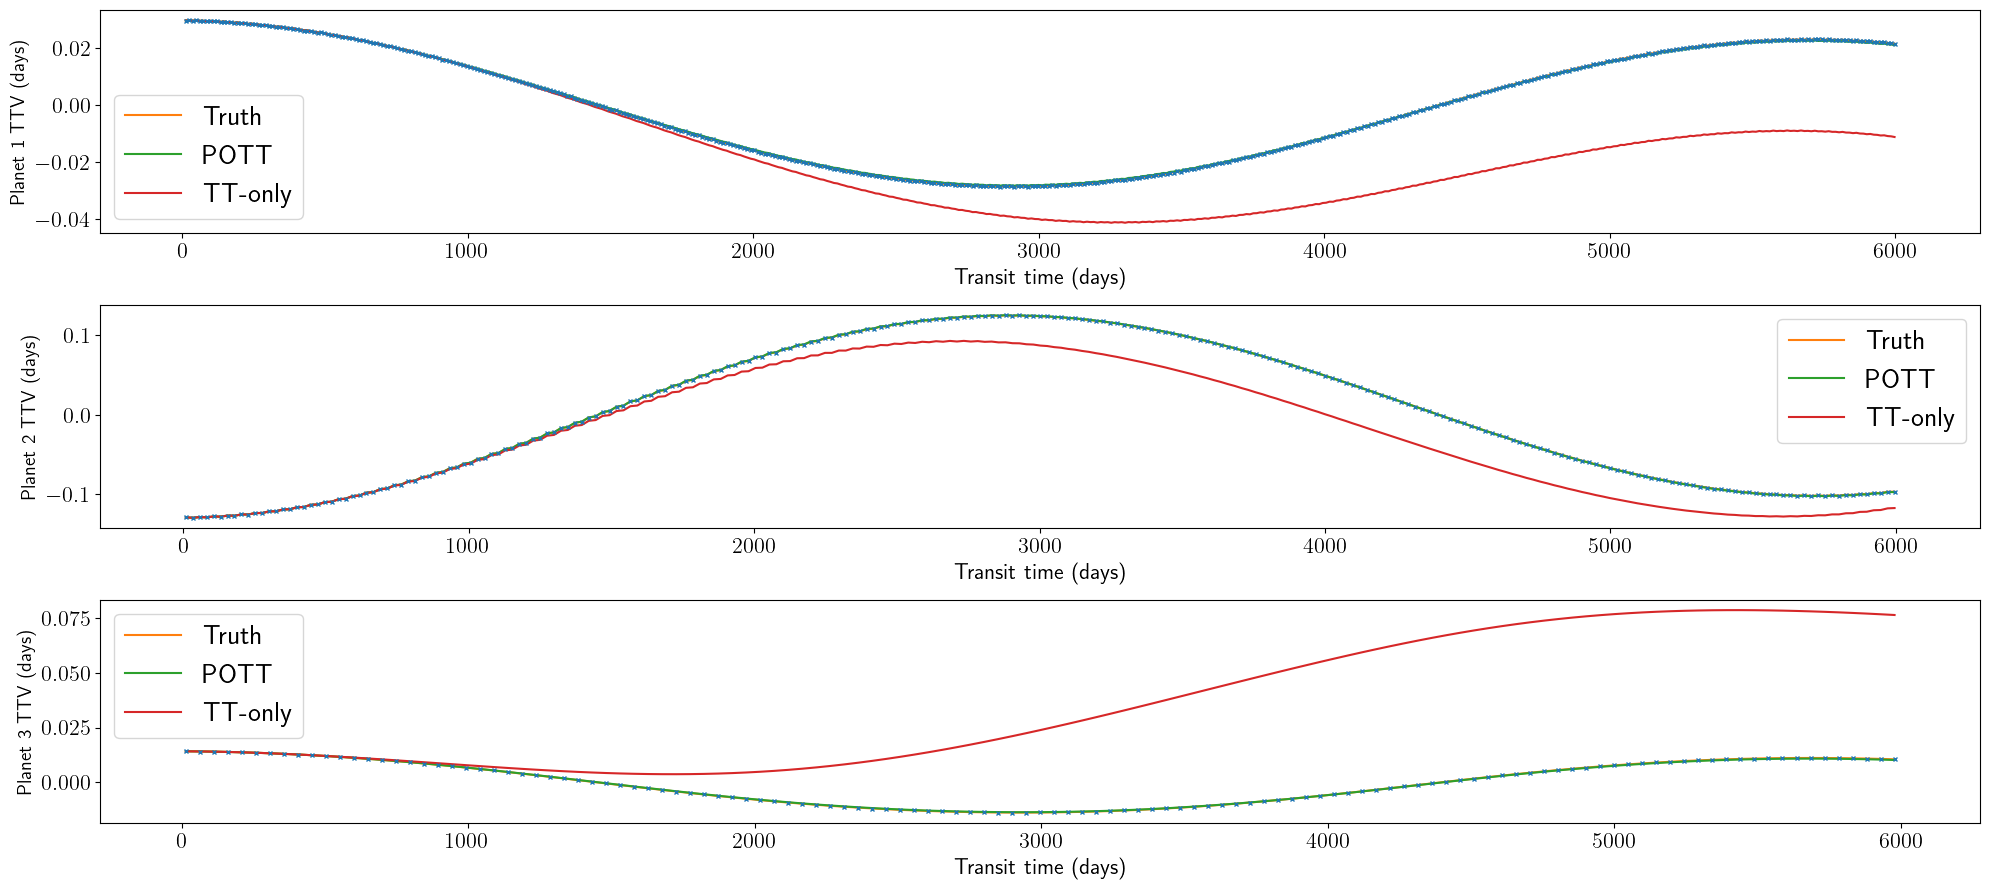

In [14]:
tt_obj = jldopen("run_freq_multi_noise_01s_07_03s_longer_data_only.jld2");
tt_obj_short = jldopen("run_freq_multi_noise_01s_07_03s_data_only.jld2");

tt_data = tt_obj["tt"][converged_all[1]]
tt_data_short = tt_obj_short["tt"][converged_all[1]]

tt_clean = to_matrix(tt.tt; err=0)
tt_clean_long = to_matrix(tt_long.tt; err=0)

tt_model = to_matrix(tt_1.tt; err=0)
tt_model_long = to_matrix(tt_1_long.tt; err=0)
tt_model_tt = to_matrix(tt_2.tt; err=0)
tt_model_tt_long = to_matrix(tt_2_long.tt; err=0)

fig, ax = subplots(3, 1, figsize=(20,9), tight_layout=true)

for i in 1:3
    cal_transits = estimate_period(tt_data, i, [10., 0.])[2];
    obs_transits = tt_data[tt_data[:,1] .== convert(Float64,i),3];
    
    ax[i].errorbar(obs_transits, obs_transits .- cal_transits, yerr = tt_data[tt_data[:,1] .== convert(Float64,i),4], 
        fmt="x", linestyle="", markersize=3, linewidth=1)

    # cal_transits_coeffs = estimate_period(tt_clean_long, i, [10., 0.])[1];
    # cal_transits = linear.(0:(sum(tt_clean_long[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_clean_long[tt_clean_long[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="Truth")

    # cal_transits_coeffs = estimate_period(tt_model_long, i, [10., 0.])[1];
    # cal_transits = linear.(0:(sum(tt_model_long[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_model_long[tt_model_long[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="POTT")

    # cal_transits_coeffs = estimate_period(tt_model_tt_long, i, [10., 0.])[1];
    # cal_transits = linear.(0:(sum(tt_model_tt_long[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_model_tt_long[tt_model_tt_long[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="TT-only")

    ax[i].set_ylabel("Planet $i TTV (days)", fontsize=14)
    ax[i].set_xlabel("Transit time (days)", fontsize=16)

    ax[i].tick_params(labelsize=16)

    ax[i].legend(fontsize=20)

    # ax[i].set_xlim(5500, 6000)
end

fig.savefig("figures/ttv_signals_03s_long.pdf")

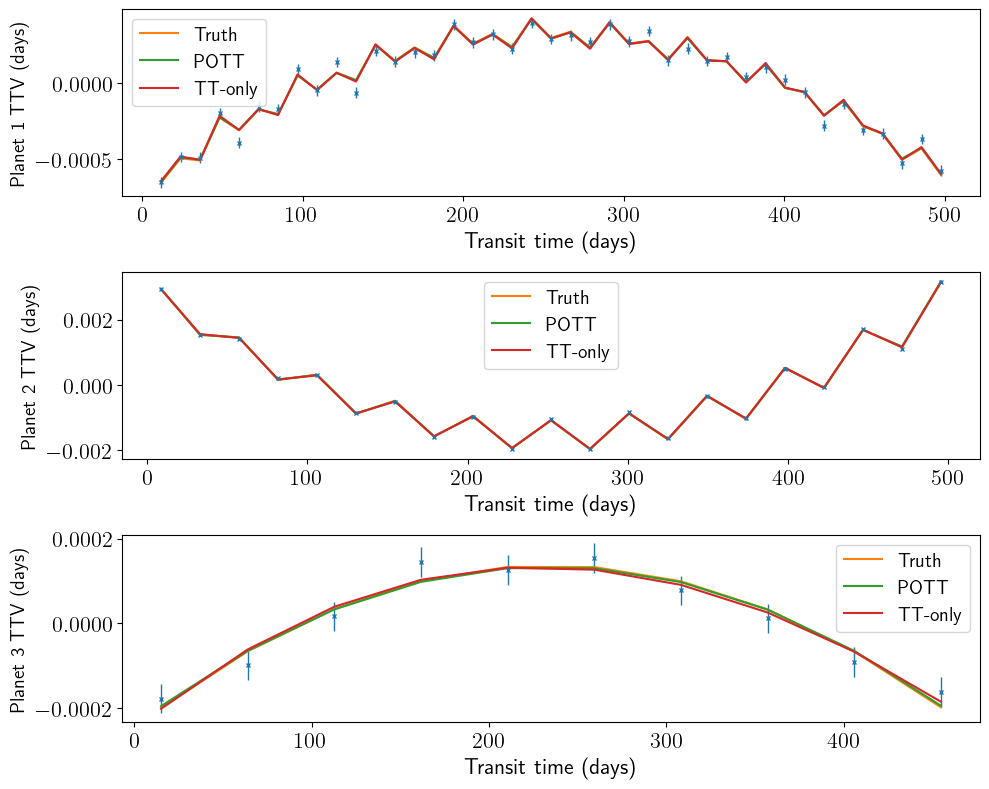

In [15]:
tt_obj = jldopen("run_freq_multi_noise_01s_07_03s_longer_data_only.jld2");
tt_obj_short = jldopen("run_freq_multi_noise_01s_07_03s_data_only.jld2");

tt_data = tt_obj_short["tt"][converged_all[1]]
# tt_data_short = tt_obj_short["tt"][converged_all[1]]

tt_clean = to_matrix(tt.tt; err=0)
tt_clean_long = to_matrix(tt_long.tt; err=0)

tt_model = to_matrix(tt_1.tt; err=0)
tt_model_long = to_matrix(tt_1_long.tt; err=0)
tt_model_tt = to_matrix(tt_2.tt; err=0)
tt_model_tt_long = to_matrix(tt_2_long.tt; err=0)

fig, ax = subplots(3, 1, figsize=(10,8), tight_layout=true)

for i in 1:3
    cal_transits = estimate_period(tt_data, i, [10., 0.])[2];
    obs_transits = tt_data[tt_data[:,1] .== convert(Float64,i),3];
    
    ax[i].errorbar(obs_transits, obs_transits .- cal_transits, yerr = tt_data[tt_data[:,1] .== convert(Float64,i),4], 
        fmt="x", linestyle="", markersize=3, linewidth=1)
    
    cal_transits_coeffs = estimate_period(tt_clean, i, [10., 0.])[1];
    cal_transits = linear.(0:(sum(tt_clean[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_clean[tt_clean[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="Truth")

    cal_transits_coeffs = estimate_period(tt_model, i, [10., 0.])[1];
    cal_transits = linear.(0:(sum(tt_model[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_model[tt_model[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="POTT")

    cal_transits_coeffs = estimate_period(tt_model_tt, i, [10., 0.])[1];
    cal_transits = linear.(0:(sum(tt_model_tt[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_model_tt[tt_model_tt[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="TT-only")

    ax[i].set_ylabel("Planet $i TTV (days)", fontsize=14)
    ax[i].set_xlabel("Transit time (days)", fontsize=16)

    ax[i].tick_params(labelsize=16)

    ax[i].legend(fontsize=14)

    # ax[i].set_xlim(5500, 6000)
end

fig.savefig("figures/ttv_signals_03s_short.pdf")

In [16]:
# Compute the TTV super-period

In [17]:
# Clean orbit
orbparams = OrbitParameters(3, [0.5], 500.)
optparams_0 = OptimParameters(3, clean_params)

orbit_0 = Orbit(3, optparams_0, orbparams)
tt = compute_tt(orbit_0, orbparams.obstmax);

# Clean orbit long
orbparams = OrbitParameters(3, [0.5], 20000.)
optparams_0_long = OptimParameters(3, clean_params)

orbit_0_long = Orbit(3, optparams_0_long, orbparams)
tt_long = compute_tt(orbit_0_long, orbparams.obstmax);

# Noisy orbit POTT (3 s)
params_all = reduce(hcat, [[(obj_03s["optres"][i][100].param .* obj_03s["scaler"][i])[param_idx] for i in converged_all] for param_idx in 1:16]);
orbparams = OrbitParameters(3, [0.5], 500.)
optparams_1 = OptimParameters(3, params_all[1,:])

orbit_1 = Orbit(3, optparams_1, orbparams)
tt_1 = compute_tt(orbit_1, orbparams.obstmax);

# Noisy orbit POTT long (3 s)
params_all = reduce(hcat, [[(obj_03s["optres"][i][100].param .* obj_03s["scaler"][i])[param_idx] for i in converged_all] for param_idx in 1:16]);
orbparams = OrbitParameters(3, [0.5], 20000.)
optparams_1_long = OptimParameters(3, params_all[1,:])

orbit_1_long = Orbit(3, optparams_1_long, orbparams)
tt_1_long = compute_tt(orbit_1_long, orbparams.obstmax);

# Noisy orbit TT (3 s)
params_all_tt = reduce(hcat, [[(obj_03s["optres"][i][1].param .* obj_03s["scaler"][i])[param_idx] for i in converged_all] for param_idx in 1:16]);
orbparams = OrbitParameters(3, [0.5], 500.)
optparams_2 = OptimParameters(3, params_all_tt[1,:])

orbit_2 = Orbit(3, optparams_2, orbparams)
tt_2 = compute_tt(orbit_2, orbparams.obstmax);

# Noisy orbit TT long (3 s)
params_all_tt = reduce(hcat, [[(obj_03s["optres"][i][1].param .* obj_03s["scaler"][i])[param_idx] for i in converged_all] for param_idx in 1:16]);
orbparams = OrbitParameters(3, [0.5], 20000.)
optparams_2_long = OptimParameters(3, params_all_tt[1,:])

orbit_2_long = Orbit(3, optparams_2_long, orbparams)
tt_2_long = compute_tt(orbit_2_long, orbparams.obstmax);

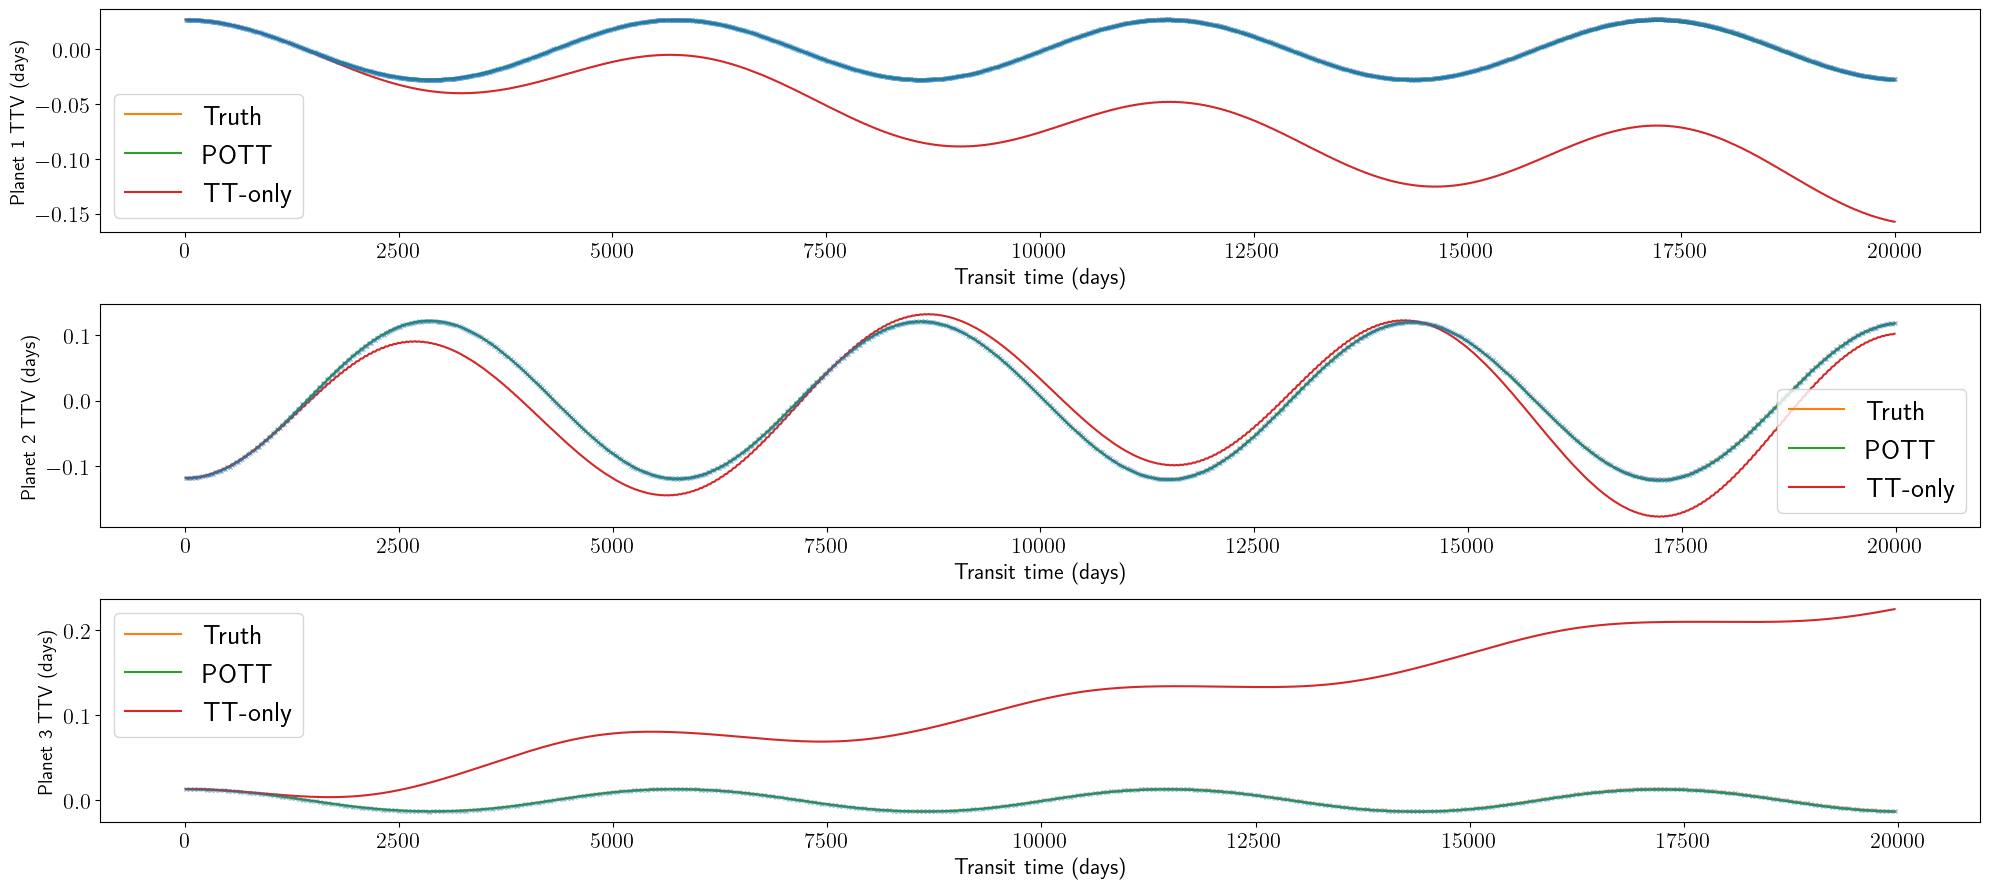

In [18]:
tt_obj = jldopen("run_freq_multi_noise_01s_07_03s_longer_data_only_02.jld2");
tt_obj_short = jldopen("run_freq_multi_noise_01s_07_03s_data_only.jld2");

tt_data = tt_obj["tt"][converged_all[1]]
tt_data_short = tt_obj_short["tt"][converged_all[1]]

tt_clean = to_matrix(tt.tt; err=0)
tt_clean_long = to_matrix(tt_long.tt; err=0)

tt_model = to_matrix(tt_1.tt; err=0)
tt_model_long = to_matrix(tt_1_long.tt; err=0)
tt_model_tt = to_matrix(tt_2.tt; err=0)
tt_model_tt_long = to_matrix(tt_2_long.tt; err=0)

fig, ax = subplots(3, 1, figsize=(20,9), tight_layout=true)

for i in 1:3
    cal_transits = estimate_period(tt_data, i, [10., 0.])[2];
    obs_transits = tt_data[tt_data[:,1] .== convert(Float64,i),3];
    
    ax[i].errorbar(obs_transits, obs_transits .- cal_transits, yerr = tt_data[tt_data[:,1] .== convert(Float64,i),4], 
        fmt="x", linestyle="", markersize=3, linewidth=1, alpha=0.5)

    # cal_transits_coeffs = estimate_period(tt_clean_long, i, [10., 0.])[1];
    # cal_transits = linear.(0:(sum(tt_clean_long[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_clean_long[tt_clean_long[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="Truth")

    # cal_transits_coeffs = estimate_period(tt_model_long, i, [10., 0.])[1];
    # cal_transits = linear.(0:(sum(tt_model_long[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_model_long[tt_model_long[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="POTT")

    # cal_transits_coeffs = estimate_period(tt_model_tt_long, i, [10., 0.])[1];
    # cal_transits = linear.(0:(sum(tt_model_tt_long[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_model_tt_long[tt_model_tt_long[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="TT-only")

    ax[i].set_ylabel("Planet $i TTV (days)", fontsize=14)
    ax[i].set_xlabel("Transit time (days)", fontsize=16)

    ax[i].tick_params(labelsize=16)

    ax[i].legend(fontsize=20)

    # ax[i].set_xlim(5500, 6000)
end

fig.savefig("figures/ttv_signals_03s_longer.pdf")

# TTV Super-period

In [19]:
using LombScargle

In [20]:
best_periods = Vector{Float64}(undef, 3)

for i in 1:3
    cal_transits = estimate_period(tt_data, i, [10., 0.])[2];
    obs_transits = tt_data[tt_data[:,1] .== convert(Float64,i),3];

    plan = lombscargle(obs_transits, obs_transits .- cal_transits)
    @show best_periods[i] = findmaxperiod(plan, [1000, 7000])[1]
end

best_periods[i] = (findmaxperiod(plan, [1000, 7000]))[1] = 5710.298006701215
best_periods[i] = (findmaxperiod(plan, [1000, 7000]))[1] = 5708.576557327887
best_periods[i] = (findmaxperiod(plan, [1000, 7000]))[1] = 5697.88352858831


In [21]:
# average super-period
mean(best_periods)

5705.5860308724705